In [20]:
# RESOURCES
# DATA: https://ridewithgps.com/explore?b=u&q=TransDinarica (all the routes have been taken from here and the analysis have been done only on these assets)
print('hello world')

hello world


In [5]:
!pip install folium gpxpy geopy scikit-learn matplotlib seaborn pandas geopandas numpy shapely requests branca
#foookingg dependenciesss

In [60]:
# TransDinarica Route Analysis - Full Version
# This version analyzes all 8 GPX files and creates comprehensive visualizations

# Import required libraries
import os
import gpxpy
import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import numpy as np
from IPython.display import display, Image
import time

# 1. Define the Working Directory
# ------------------------------
working_project = "C:\\Users\\alex\\PycharmProjects\\transDinaricaRoute\\assets\\"


In [61]:

# 2. List all GPX files
# -----------------
# List of all TransDinarica GPX files to analyze
gpx_files = [
    'transdinarica_1.gpx',
    'transdinarica_2.gpx',
    'transdinarica_3.gpx',
    'transdinarica_4.gpx',
    'transdinarica_5.gpx',
    'transdinarica_6.gpx',
    'transdinarica_7.gpx',
    'transdinarica_8.gpx'
]


In [62]:

# 3. Define a robust GPX loading function
# -------------------------------------
def load_gpx_files_robust(file_list, base_path):
    """Load GPX files with robust error handling for different formats and corrupted files"""
    routes = []

    for file in file_list:
        file_path = os.path.join(base_path, file)
        try:
            with open(file_path, 'r', encoding='utf-8') as gpx_file:
                # First try standard parsing
                try:
                    gpx = gpxpy.parse(gpx_file)
                except Exception as parse_error:
                    print(f"Standard parsing failed for {file}, trying with error recovery: {parse_error}")

                    # If standard parsing fails, try to fix common issues
                    gpx_file.seek(0)  # Go back to start of file
                    gpx_content = gpx_file.read()

                    # Fix for truncated files - add closing tags if missing
                    if "</trkseg>" not in gpx_content:
                        gpx_content += "</trkseg></trk></gpx>"

                    # Try to parse the fixed content
                    try:
                        gpx = gpxpy.parse(gpx_content)
                    except Exception as recovery_error:
                        print(f"Could not recover {file}: {recovery_error}")
                        continue

                # Extract track data - with heavy sampling for large files
                for track in gpx.tracks:
                    for segment in track.segments:
                        # Determine sampling rate based on point count
                        # More aggressive sampling for very large files
                        if len(segment.points) > 10000:
                            sample_rate = 50  # Take every 50th point
                        elif len(segment.points) > 5000:
                            sample_rate = 20  # Take every 20th point
                        elif len(segment.points) > 1000:
                            sample_rate = 10  # Take every 10th point
                        elif len(segment.points) > 500:
                            sample_rate = 5   # Take every 5th point
                        else:
                            sample_rate = 1   # Take all points

                        # Extract all valid points with sampling
                        points = []
                        for i, point in enumerate(segment.points):
                            if i % sample_rate != 0:  # Skip based on sampling rate
                                continue

                            # Validate the point has required attributes
                            if hasattr(point, 'latitude') and hasattr(point, 'longitude'):
                                try:
                                    lat = float(point.latitude)
                                    lon = float(point.longitude)
                                    ele = float(point.elevation) if point.elevation is not None else None

                                    # Only add valid points (within reasonable ranges)
                                    if -90 <= lat <= 90 and -180 <= lon <= 180:
                                        points.append((lat, lon, ele))
                                except (ValueError, TypeError) as e:
                                    # Skip points with invalid values
                                    continue

                        if points:  # Only add if we have valid points
                            routes.append({'file': file, 'points': points})

                            # Log success with point count
                            print(f"Successfully loaded {file} with {len(points)} points (sampled from {len(segment.points)})")
        except Exception as e:
            print(f"Error loading {file}: {e}")

    return routes


In [63]:

# 4. Define the Geographic Region
# ------------------------------
# Simplified country boundaries for the TransDinarica region
countries_info = {
    "Slovenia": {"bounds": [45.4, 46.9, 13.4, 16.6], "color": "#1f77b4"},
    "Croatia": {"bounds": [42.3, 46.5, 13.5, 19.4], "color": "#ff7f0e"},
    "Bosnia and Herzegovina": {"bounds": [42.5, 45.3, 15.7, 19.6], "color": "#2ca02c"},
    "Montenegro": {"bounds": [41.8, 43.6, 18.4, 20.4], "color": "#d62728"},
    "Albania": {"bounds": [39.6, 42.7, 19.2, 21.1], "color": "#9467bd"},
    "Kosovo": {"bounds": [41.8, 43.3, 20.0, 21.8], "color": "#8c564b"},
    "North Macedonia": {"bounds": [40.8, 42.4, 20.4, 23.0], "color": "#e377c2"},
    "Serbia": {"bounds": [42.2, 46.2, 18.8, 23.0], "color": "#7f7f7f"}
}

In [64]:


# 5. Helper Functions
# ------------------
def route_distance(points):
    """Calculate the total distance of a route in kilometers"""
    distance = 0.0
    for i in range(1, len(points)):
        try:
            p1 = (float(points[i-1][0]), float(points[i-1][1]))
            p2 = (float(points[i][0]), float(points[i][1]))
            distance += geodesic(p1, p2).kilometers
        except (ValueError, TypeError, IndexError):
            continue
    return distance

def elevation_stats(points):
    """Calculate comprehensive elevation statistics"""
    elevations = []
    gain = 0.0
    loss = 0.0

    for i in range(1, len(points)):
        try:
            if len(points[i]) > 2 and points[i][2] is not None and len(points[i-1]) > 2 and points[i-1][2] is not None:
                current_ele = float(points[i][2])
                prev_ele = float(points[i-1][2])
                elevations.append(current_ele)

                # Calculate elevation change
                ele_change = current_ele - prev_ele
                if ele_change > 0:
                    gain += ele_change
                else:
                    loss += abs(ele_change)
        except (ValueError, TypeError, IndexError):
            continue

    # Add first point elevation if available
    if len(points) > 0 and len(points[0]) > 2 and points[0][2] is not None:
        try:
            elevations.append(float(points[0][2]))
        except (ValueError, TypeError):
            pass

    if not elevations:
        return 0, 0, 0, 0

    return gain, loss, max(elevations), min(elevations)

def identify_country(lat, lon, countries_info):
    """Identify which country a point belongs to based on bounding boxes"""
    for country, info in countries_info.items():
        bounds = info["bounds"]
        # Check if point is within bounds (lat_min, lat_max, lon_min, lon_max)
        if bounds[0] <= lat <= bounds[1] and bounds[2] <= lon <= bounds[3]:
            return country
    return "Unknown"

def calculate_slope(p1, p2):
    """Calculate the slope percentage between two points"""
    try:
        if len(p1) < 3 or len(p2) < 3 or p1[2] is None or p2[2] is None:
            return 0

        # Calculate distance in meters
        dist = geodesic((float(p1[0]), float(p1[1])), (float(p2[0]), float(p2[1]))).meters
        if dist == 0:
            return 0

        # Calculate elevation change in meters
        elev_change = float(p2[2]) - float(p1[2])

        # Calculate slope as percentage
        slope_pct = (elev_change / dist) * 100

        return slope_pct
    except (ValueError, TypeError, IndexError, ZeroDivisionError):
        return 0


In [65]:

# 6. Load Route Data
# ----------------
print("Loading GPX files (this may take a while for large files)...")
start_time = time.time()
routes = load_gpx_files_robust(gpx_files, working_project)
print(f"Loaded {len(routes)} route segments from {len(gpx_files)} GPX files in {round(time.time() - start_time, 2)} seconds")


Loading GPX files (this may take a while for large files)...
Successfully loaded transdinarica_1.gpx with 459 points (sampled from 9167)
Successfully loaded transdinarica_2.gpx with 250 points (sampled from 12474)
Successfully loaded transdinarica_3.gpx with 487 points (sampled from 4870)
Successfully loaded transdinarica_4.gpx with 360 points (sampled from 3599)
Successfully loaded transdinarica_5.gpx with 402 points (sampled from 4011)
Successfully loaded transdinarica_6.gpx with 220 points (sampled from 10981)
Successfully loaded transdinarica_7.gpx with 141 points (sampled from 1407)
Successfully loaded transdinarica_8.gpx with 3346 points (sampled from 167254)
Loaded 8 route segments from 8 GPX files in 15.18 seconds


In [66]:

# 7. Calculate Route Statistics
# --------------------------
print("Calculating route statistics...")
route_stats = []

for route in routes:
    dist = route_distance(route['points'])
    gain, loss, max_ele, min_ele = elevation_stats(route['points'])

    route_stats.append({
        'file': route['file'],
        'distance_km': dist,
        'elevation_gain_m': gain,
        'elevation_loss_m': loss,
        'max_elevation_m': max_ele,
        'min_elevation_m': min_ele
    })

# Display route statistics
route_stats_df = pd.DataFrame(route_stats)
display(route_stats_df)

# Save statistics to CSV
route_stats_df.to_csv('transdinarica_route_stats.csv', index=False)
print("Route statistics saved to 'transdinarica_route_stats.csv'")


Calculating route statistics...


,file,distance_km,elevation_gain_m,elevation_loss_m,max_elevation_m,min_elevation_m
0,transdinarica_1.gpx,252.116473,3695.400,3329.800,797.000,2.700
1,transdinarica_2.gpx,262.064074,4848.100,5274.900,1900.900,11.000
2,transdinarica_3.gpx,109.659290,3114.600,1931.800,1901.900,479.500
3,transdinarica_4.gpx,86.033500,1596.400,2315.100,1749.500,751.000
4,transdinarica_5.gpx,103.494660,1773.600,2679.300,1358.700,8.300
5,transdinarica_6.gpx,439.191934,4617.800,4617.000,1258.700,45.200
6,transdinarica_7.gpx,44.310374,1472.031,755.820,1893.070,658.067
7,transdinarica_8.gpx,1059.312340,17941.171,17976.388,1897.486,5.027


Route statistics saved to 'transdinarica_route_stats.csv'


Creating complete route map...


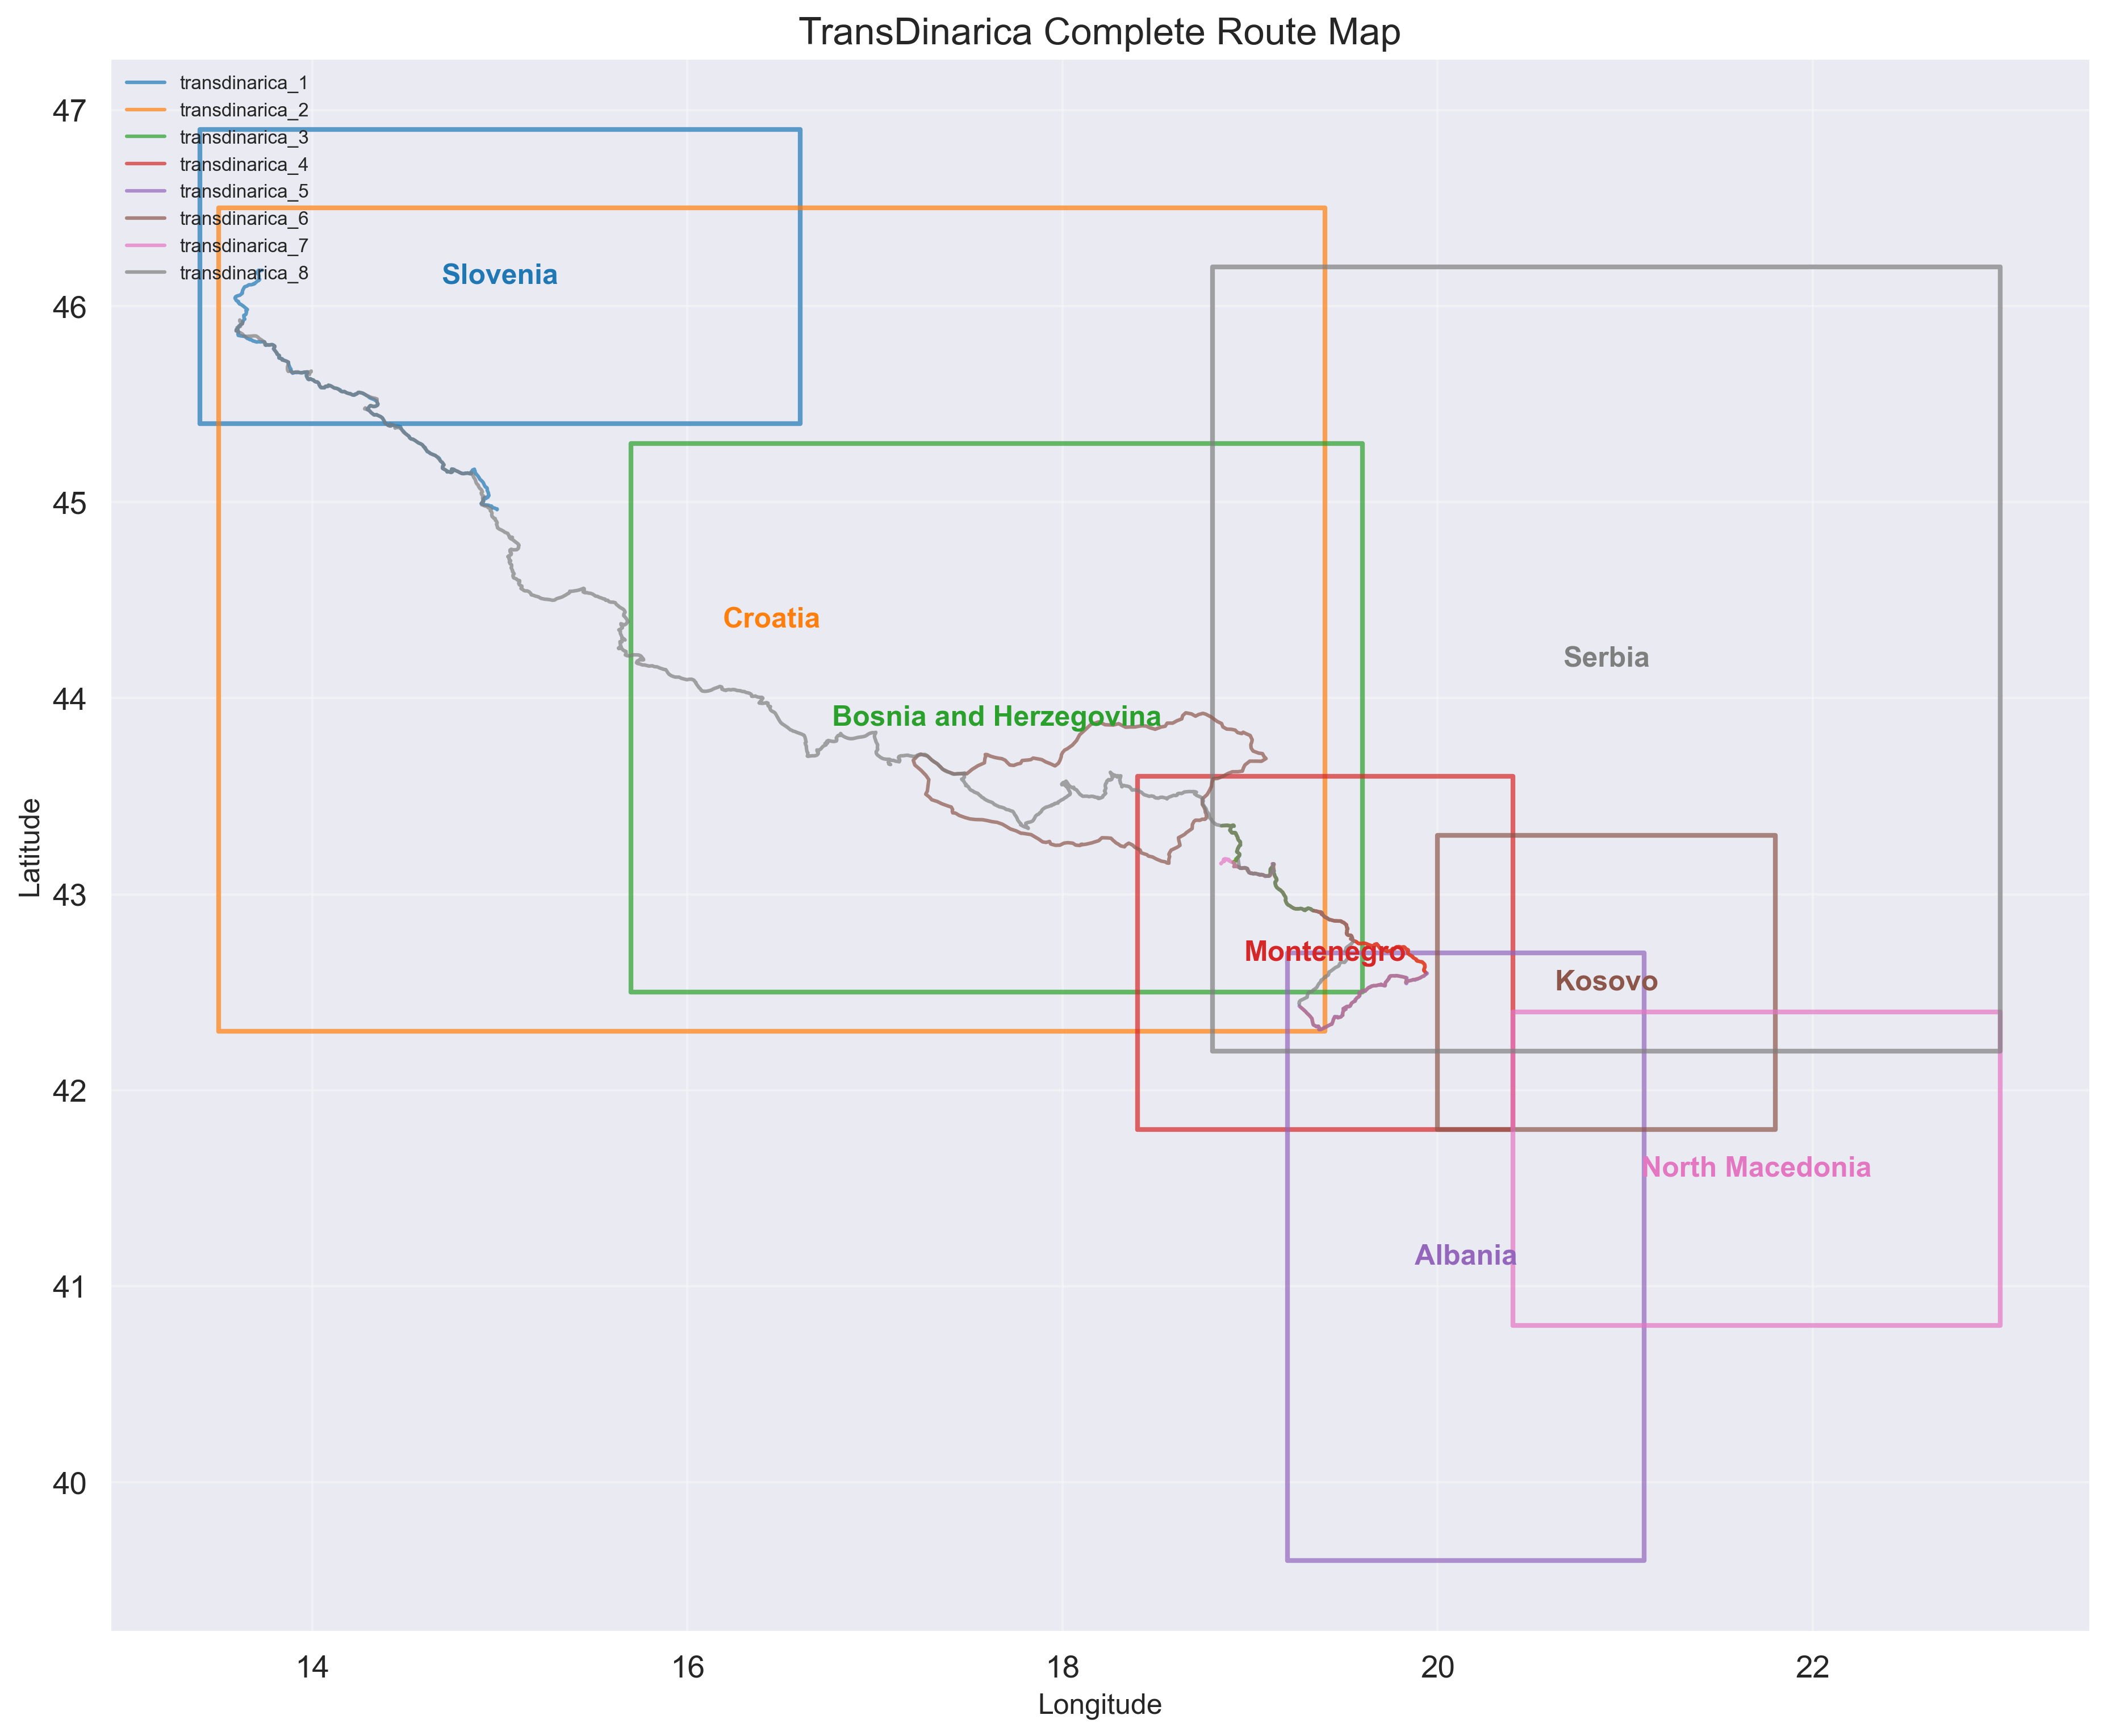

Complete route map saved to 'transdinarica_complete_map.png'


In [67]:

# 8. Create Complete Route Map
# -------------------------
def create_full_route_map():
    """Create a comprehensive map of all TransDinarica routes"""
    plt.figure(figsize=(15, 12))

    # Plot country boundaries
    for country, info in countries_info.items():
        bounds = info["bounds"]
        color = info["color"]

        # Create rectangle for country (simplified)
        lat_min, lat_max, lon_min, lon_max = bounds
        plt.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                 [lat_min, lat_min, lat_max, lat_max, lat_min],
                 color=color, linewidth=2, alpha=0.7)

        # Add country label
        plt.text((lon_min + lon_max)/2, (lat_min + lat_max)/2, country,
                 fontsize=12, ha='center', va='center', color=color, fontweight='bold')

    # Plot all routes with different colors
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    # Create legend handles
    legend_handles = []

    for idx, route in enumerate(routes):
        # Get route name for legend (without extension)
        route_name = os.path.splitext(route['file'])[0]
        color = colors[idx % len(colors)]

        # Extract coordinates with appropriate sampling for display
        if len(route['points']) > 2000:
            sample_rate = len(route['points']) // 1000  # Limit to ~1000 points for display
            display_points = route['points'][::sample_rate]
        else:
            display_points = route['points']

        lats = []
        lons = []
        for p in display_points:
            try:
                if len(p) >= 2:
                    lat, lon = float(p[0]), float(p[1])
                    lats.append(lat)
                    lons.append(lon)
            except (ValueError, TypeError):
                continue

        if lats and lons:
            # Plot the route
            line, = plt.plot(lons, lats, '-', color=color, linewidth=1.5, alpha=0.7)
            legend_handles.append((line, route_name))

    # Add legend
    plt.legend([h for h, l in legend_handles],
               [l for h, l in legend_handles],
               loc='upper left', fontsize=8)

    plt.title('TransDinarica Complete Route Map', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.savefig('transdinarica_complete_map.png', dpi=300, bbox_inches='tight')
    plt.close()

    return 'transdinarica_complete_map.png'

# Create and display full route map
print("Creating complete route map...")
complete_map = create_full_route_map()
display(Image(complete_map))
print("Complete route map saved to 'transdinarica_complete_map.png'")


Analyzing route distribution by country...


,Country,Distance_km,Point_count,Avg_elevation_m
1,Croatia,1621.2,1922,945.0
0,Slovenia,278.9,375,372.7
3,Montenegro,241.4,666,862.5
2,Bosnia and Herzegovina,106.1,185,975.9


Country statistics saved to 'transdinarica_country_stats.csv'


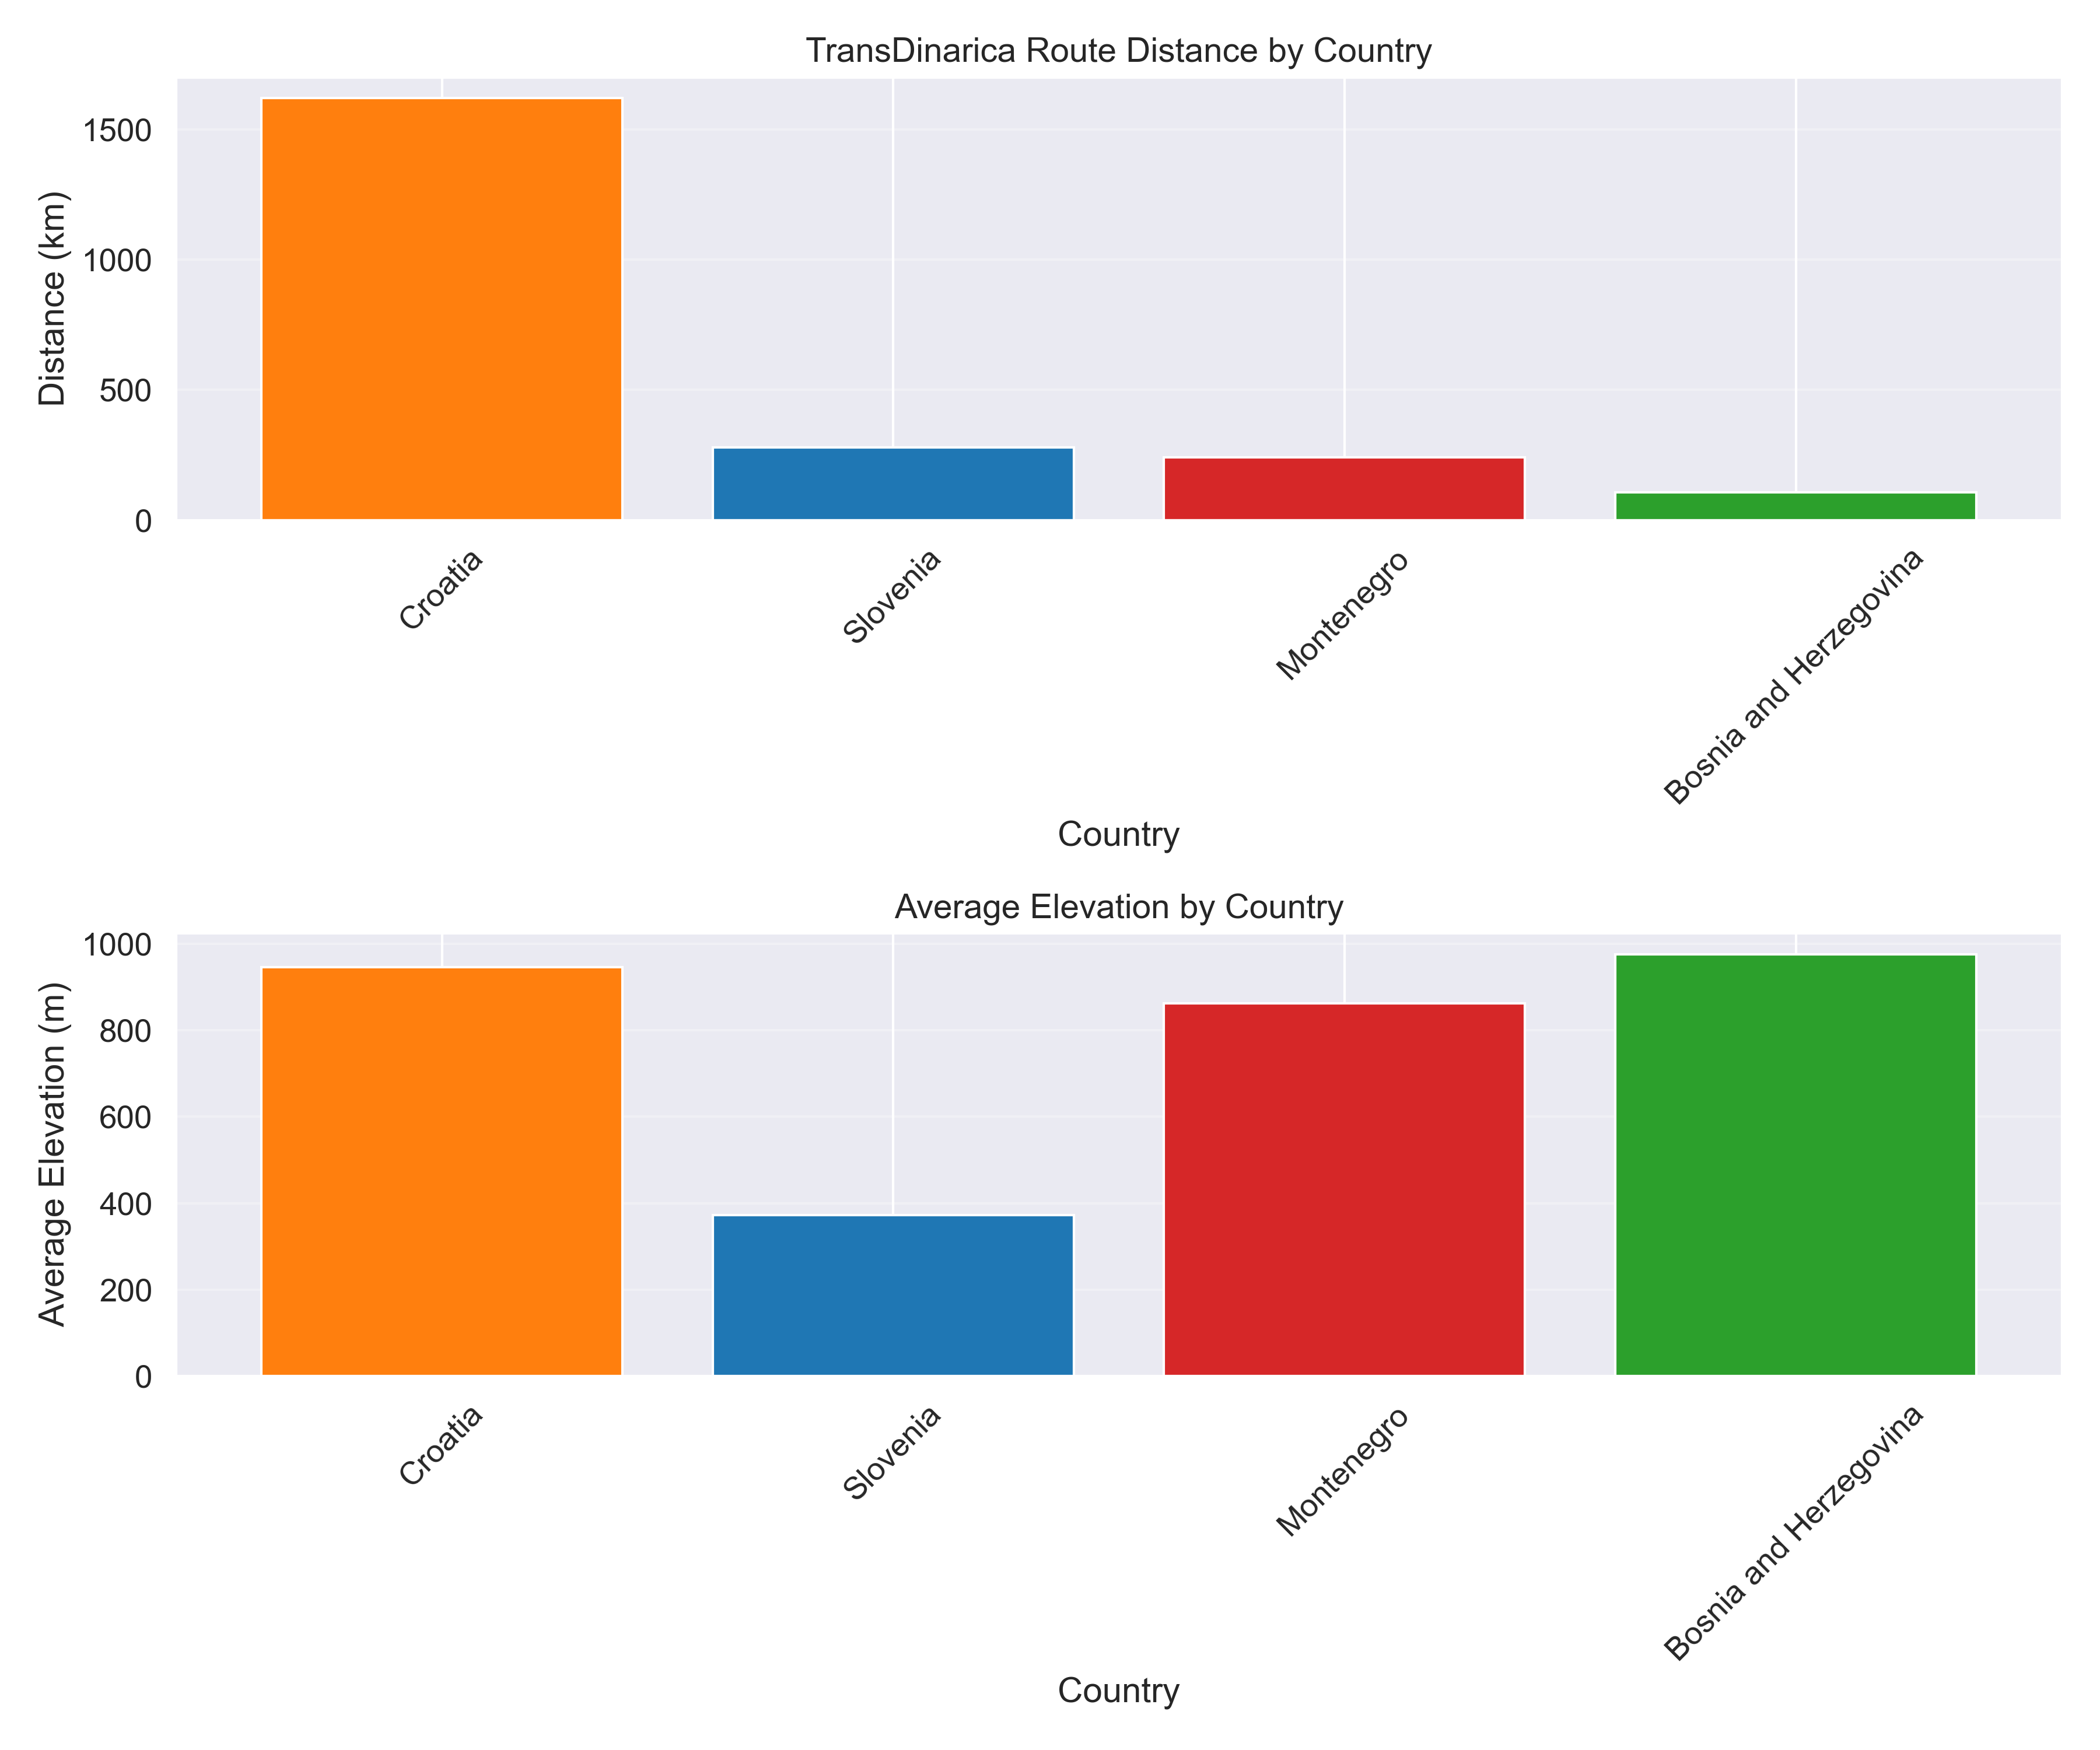

Country analysis visualization saved to 'transdinarica_country_analysis.png'


In [68]:

# 9. Country Distribution Analysis
# ----------------------------
print("Analyzing route distribution by country...")
country_distances = {country: 0 for country in countries_info.keys()}
country_points = {country: 0 for country in countries_info.keys()}
country_elevation = {country: [] for country in countries_info.keys()}

# Process all routes
for route in routes:
    points = route['points']

    # Skip routes with too few points
    if len(points) < 2:
        continue

    # For large routes, analyze a subset of points
    if len(points) > 1000:
        step = len(points) // 1000 + 1
        analysis_points = points[::step]
    else:
        analysis_points = points

    # Analyze country distribution
    for i in range(1, len(analysis_points)):
        try:
            p1 = analysis_points[i-1]
            p2 = analysis_points[i]

            # Ensure we have valid coordinates
            if len(p1) < 2 or len(p2) < 2:
                continue

            p1_lat = float(p1[0])
            p1_lon = float(p1[1])

            # Calculate segment distance
            dist = geodesic((p1_lat, p1_lon), (float(p2[0]), float(p2[1]))).kilometers

            # Identify country
            country = identify_country(p1_lat, p1_lon, countries_info)
            if country != "Unknown":
                country_distances[country] += dist
                country_points[country] += 1

                # Store elevation if available
                if len(p1) > 2 and p1[2] is not None:
                    try:
                        country_elevation[country].append(float(p1[2]))
                    except (ValueError, TypeError):
                        pass
        except (ValueError, TypeError, IndexError):
            continue

# Create DataFrame for visualization
country_data = []
for country, distance in country_distances.items():
    if distance > 0:  # Only include countries with route presence
        # Calculate average elevation if data exists
        avg_elevation = np.mean(country_elevation[country]) if country_elevation[country] else 0

        country_data.append({
            'Country': country,
            'Distance_km': round(distance, 1),
            'Point_count': country_points[country],
            'Avg_elevation_m': round(avg_elevation, 1)
        })

country_df = pd.DataFrame(country_data)
if not country_df.empty:
    country_df = country_df.sort_values('Distance_km', ascending=False)
display(country_df)

# Save country statistics to CSV
country_df.to_csv('transdinarica_country_stats.csv', index=False)
print("Country statistics saved to 'transdinarica_country_stats.csv'")

# Create a comprehensive bar chart
plt.figure(figsize=(12, 10))

if not country_df.empty:
    # Plot distance by country
    plt.subplot(2, 1, 1)
    plt.bar(country_df['Country'], country_df['Distance_km'],
            color=[countries_info[c]['color'] for c in country_df['Country']])
    plt.title('TransDinarica Route Distance by Country', fontsize=14)
    plt.xlabel('Country')
    plt.ylabel('Distance (km)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

    # Plot average elevation by country
    plt.subplot(2, 1, 2)
    plt.bar(country_df['Country'], country_df['Avg_elevation_m'],
            color=[countries_info[c]['color'] for c in country_df['Country']])
    plt.title('Average Elevation by Country', fontsize=14)
    plt.xlabel('Country')
    plt.ylabel('Average Elevation (m)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('transdinarica_country_analysis.png', dpi=300)
    plt.close()

    # Display the chart
    display(Image('transdinarica_country_analysis.png'))
    print("Country analysis visualization saved to 'transdinarica_country_analysis.png'")
else:
    print("No country data available for visualization")


Creating comprehensive challenge visualization...


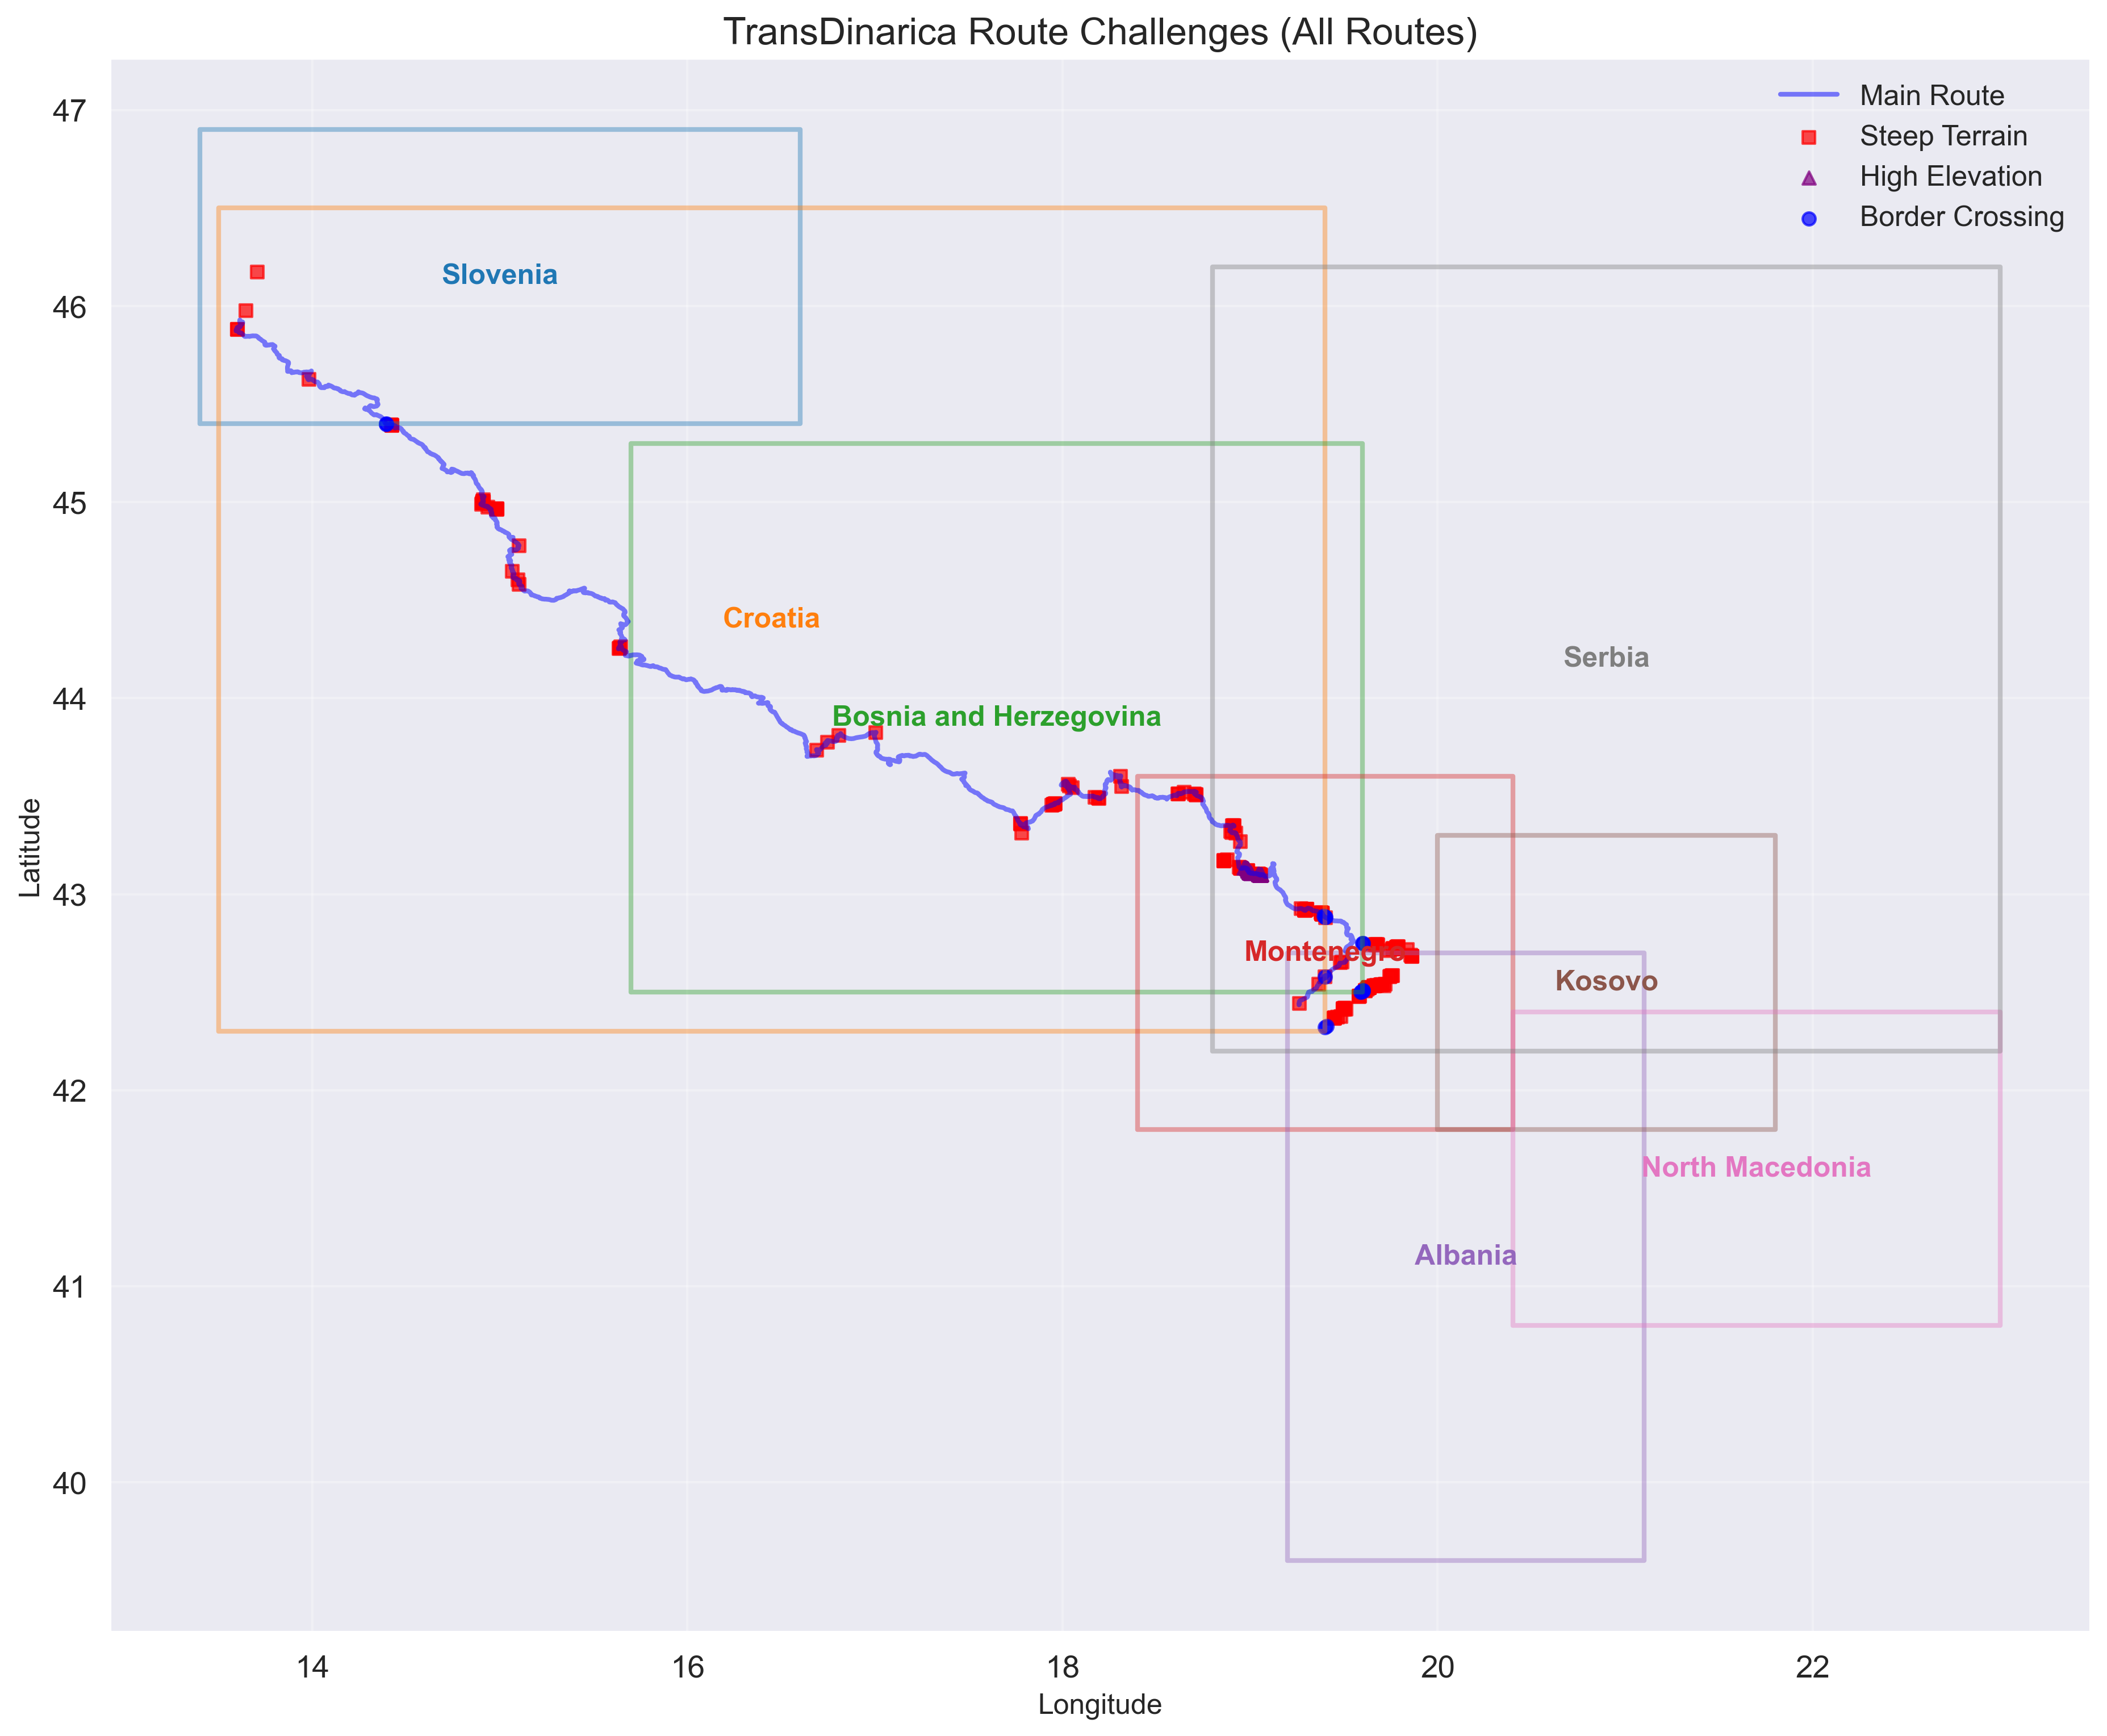

Comprehensive challenge visualization saved to 'transdinarica_comprehensive_challenges.png'


In [69]:

# 10. Comprehensive Challenge Analysis
# ---------------------------------
def create_comprehensive_challenge_map():
    """Create a detailed visualization of all challenges across the routes"""
    # Set up the plot
    plt.figure(figsize=(15, 12))

    # Plot country boundaries
    for country, info in countries_info.items():
        bounds = info["bounds"]
        color = info["color"]

        # Create rectangle for country (simplified)
        lat_min, lat_max, lon_min, lon_max = bounds
        plt.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                 [lat_min, lat_min, lat_max, lat_max, lat_min],
                 color=color, linewidth=2, alpha=0.4)

        # Add country label
        plt.text((lon_min + lon_max)/2, (lat_min + lat_max)/2, country,
                 fontsize=12, ha='center', va='center', color=color, fontweight='bold')

    # Plot main route (use route 8 as the main route since it's the largest)
    main_route = None
    for route in routes:
        if route['file'] == 'transdinarica_8.gpx':  # Use the largest file as the main route
            main_route = route
            break

    if not main_route:
        main_route = routes[0]  # Fallback to first route

    # Sample points for display
    if len(main_route['points']) > 2000:
        sample_rate = len(main_route['points']) // 2000
        display_points = main_route['points'][::sample_rate]
    else:
        display_points = main_route['points']

    main_lats = []
    main_lons = []
    for p in display_points:
        try:
            if len(p) >= 2:
                lat, lon = float(p[0]), float(p[1])
                main_lats.append(lat)
                main_lons.append(lon)
        except (ValueError, TypeError):
            continue

    if main_lats and main_lons:
        plt.plot(main_lons, main_lats, 'b-', linewidth=2, alpha=0.5, label='Main Route')

    # Collect challenge points from all routes
    steep_points = []
    high_points = []
    border_points = []

    # Process all routes
    for route in routes:
        points = route['points']

        # Skip routes with too few points
        if len(points) < 2:
            continue

        # For large routes, only analyze a subset of points
        if len(points) > 2000:
            step = len(points) // 2000 + 1
            analysis_points = points[::step]
        else:
            analysis_points = points

        # Find challenge points - steep sections and high elevations
        for i in range(1, len(analysis_points)):
            try:
                p1 = analysis_points[i-1]
                p2 = analysis_points[i]

                # Ensure we have valid coordinates
                p1_lat = float(p1[0])
                p1_lon = float(p1[1])
                p2_lat = float(p2[0])
                p2_lon = float(p2[1])

                # Calculate midpoint
                mid_lat = (p1_lat + p2_lat) / 2
                mid_lon = (p1_lon + p2_lon) / 2

                # Check for steep terrain
                slope = calculate_slope(p1, p2)
                if abs(slope) > 15:  # Steep slope
                    steep_points.append((mid_lat, mid_lon))

                # Check for high elevation
                if len(p1) > 2 and p1[2] is not None:
                    try:
                        elevation = float(p1[2])
                        if elevation > 1800:  # High elevation
                            high_points.append((p1_lat, p1_lon))
                    except (ValueError, TypeError):
                        pass

                # Check for border crossings
                country1 = identify_country(p1_lat, p1_lon, countries_info)
                country2 = identify_country(p2_lat, p2_lon, countries_info)

                if country1 != country2 and country1 != "Unknown" and country2 != "Unknown":
                    border_points.append((mid_lat, mid_lon))
            except Exception:
                continue

    # Plot challenge points
    if steep_points:
        steep_lats, steep_lons = zip(*steep_points)
        plt.scatter(steep_lons, steep_lats, c='red', marker='s', s=30, alpha=0.7, label='Steep Terrain')

    if high_points:
        high_lats, high_lons = zip(*high_points)
        plt.scatter(high_lons, high_lats, c='purple', marker='^', s=30, alpha=0.7, label='High Elevation')

    if border_points:
        border_lats, border_lons = zip(*border_points)
        plt.scatter(border_lons, border_lats, c='blue', marker='o', s=30, alpha=0.7, label='Border Crossing')

    plt.title('TransDinarica Route Challenges (All Routes)', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.savefig('transdinarica_comprehensive_challenges.png', dpi=300, bbox_inches='tight')
    plt.close()

    return 'transdinarica_comprehensive_challenges.png'

# Create and display comprehensive challenges visualization
print("Creating comprehensive challenge visualization...")
challenges_image = create_comprehensive_challenge_map()
display(Image(challenges_image))
print("Comprehensive challenge visualization saved to 'transdinarica_comprehensive_challenges.png'")


Creating elevation profiles for all routes...


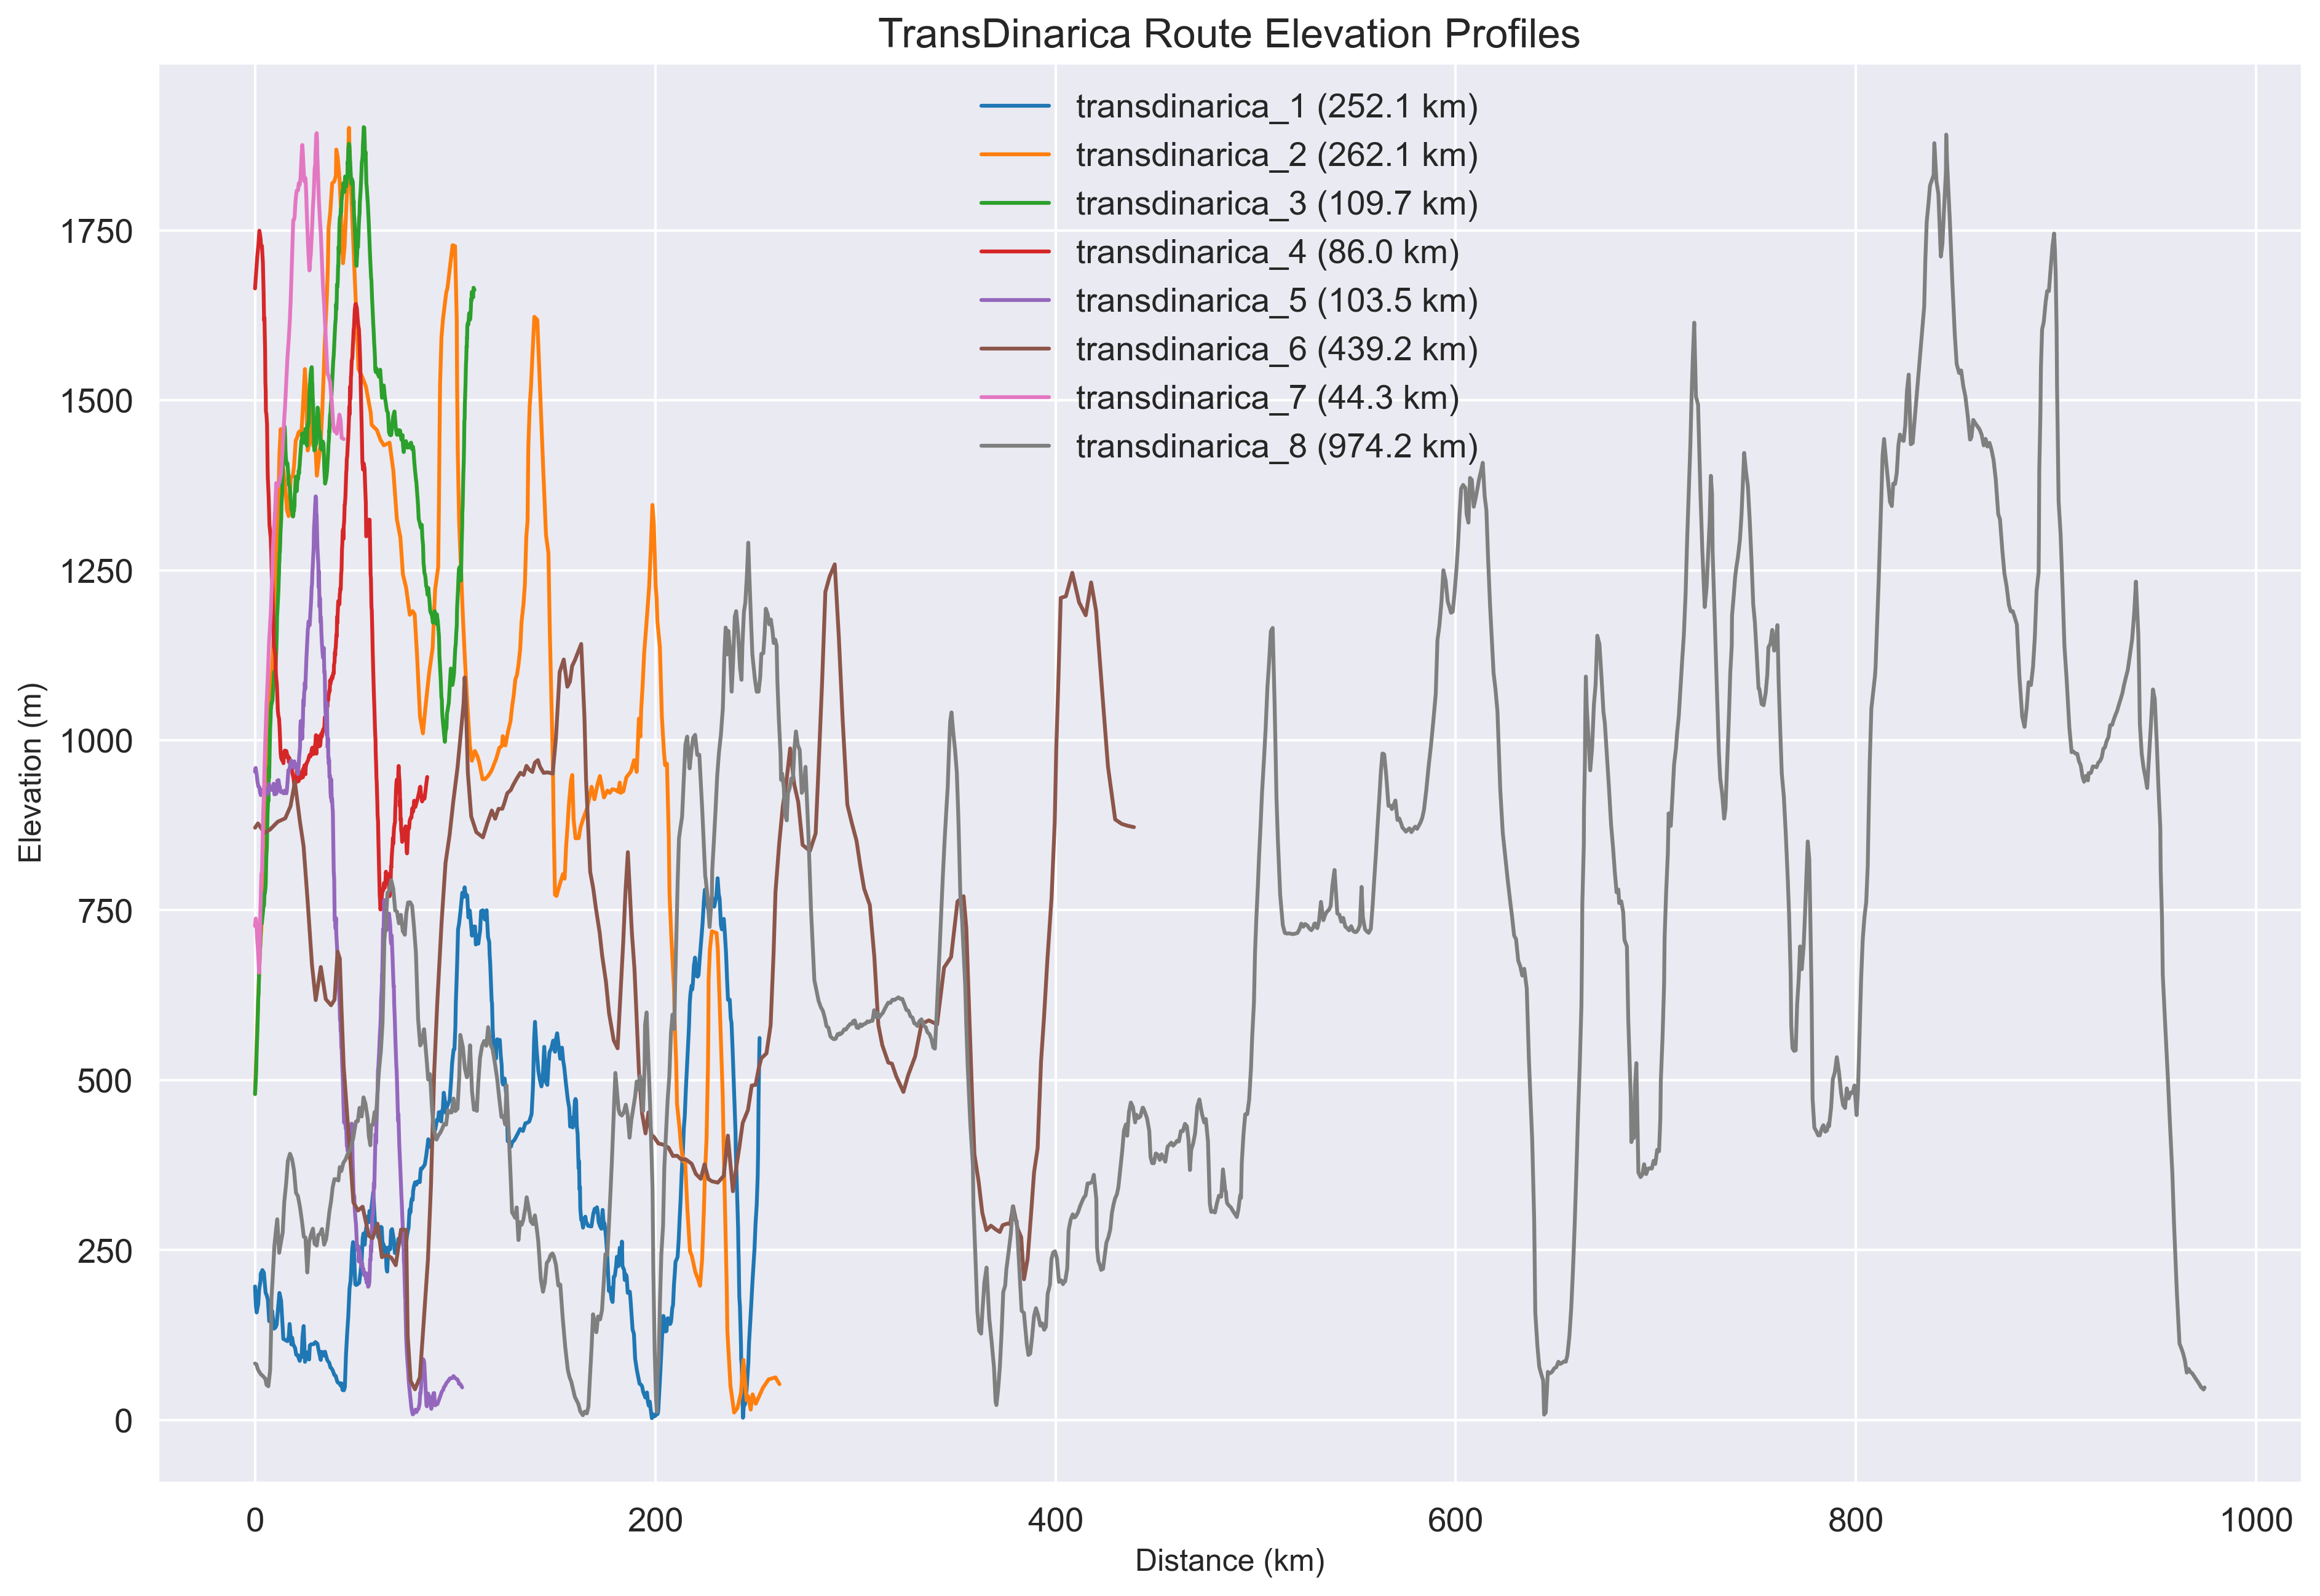

Elevation profiles saved to 'all_elevation_profiles.png'


In [71]:

# 11. Elevation Profile for Each Route
# ---------------------------------
def create_all_elevation_profiles():
    """Create elevation profiles for all routes"""
    plt.figure(figsize=(15, 10))

    # Use a maximum of 5 routes for clarity
    display_routes = routes[:min(8, len(routes))]

    for idx, route in enumerate(display_routes):
        # Get route name for legend (without extension)
        route_name = os.path.splitext(route['file'])[0]

        points = route['points']
        if len(points) < 2:
            continue

        # Sample points for large routes
        if len(points) > 1000:
            sample_rate = len(points) // 1000
            analysis_points = points[::sample_rate]
        else:
            analysis_points = points

        # Extract elevation data
        distances = [0]
        elevations = []
        valid_points = []

        for i, point in enumerate(analysis_points):
            try:
                if len(point) >= 3 and point[2] is not None:
                    # Add this point
                    lat, lon, ele = float(point[0]), float(point[1]), float(point[2])
                    valid_points.append((lat, lon, ele))
                    elevations.append(ele)

                    # Calculate distance from previous point
                    if i > 0 and len(valid_points) > 1:
                        prev = valid_points[-2]
                        dist = geodesic((prev[0], prev[1]), (lat, lon)).kilometers
                        distances.append(distances[-1] + dist)
            except (ValueError, TypeError, IndexError):
                continue

        # Skip if not enough valid points
        if len(distances) < 2 or len(elevations) < 2:
            continue

        # Plot elevation profile
        plt.plot(distances, elevations, label=f"{route_name} ({round(distances[-1], 1)} km)")

    plt.title('TransDinarica Route Elevation Profiles', fontsize=16)
    plt.xlabel('Distance (km)', fontsize=12)
    plt.ylabel('Elevation (m)', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.savefig('all_elevation_profiles.png', dpi=300, bbox_inches='tight')
    plt.close()

    return 'all_elevation_profiles.png'

# Create elevation profiles
print("Creating elevation profiles for all routes...")
profiles_image = create_all_elevation_profiles()
display(Image(profiles_image))
print("Elevation profiles saved to 'all_elevation_profiles.png'")



Creating comprehensive opportunity visualization...


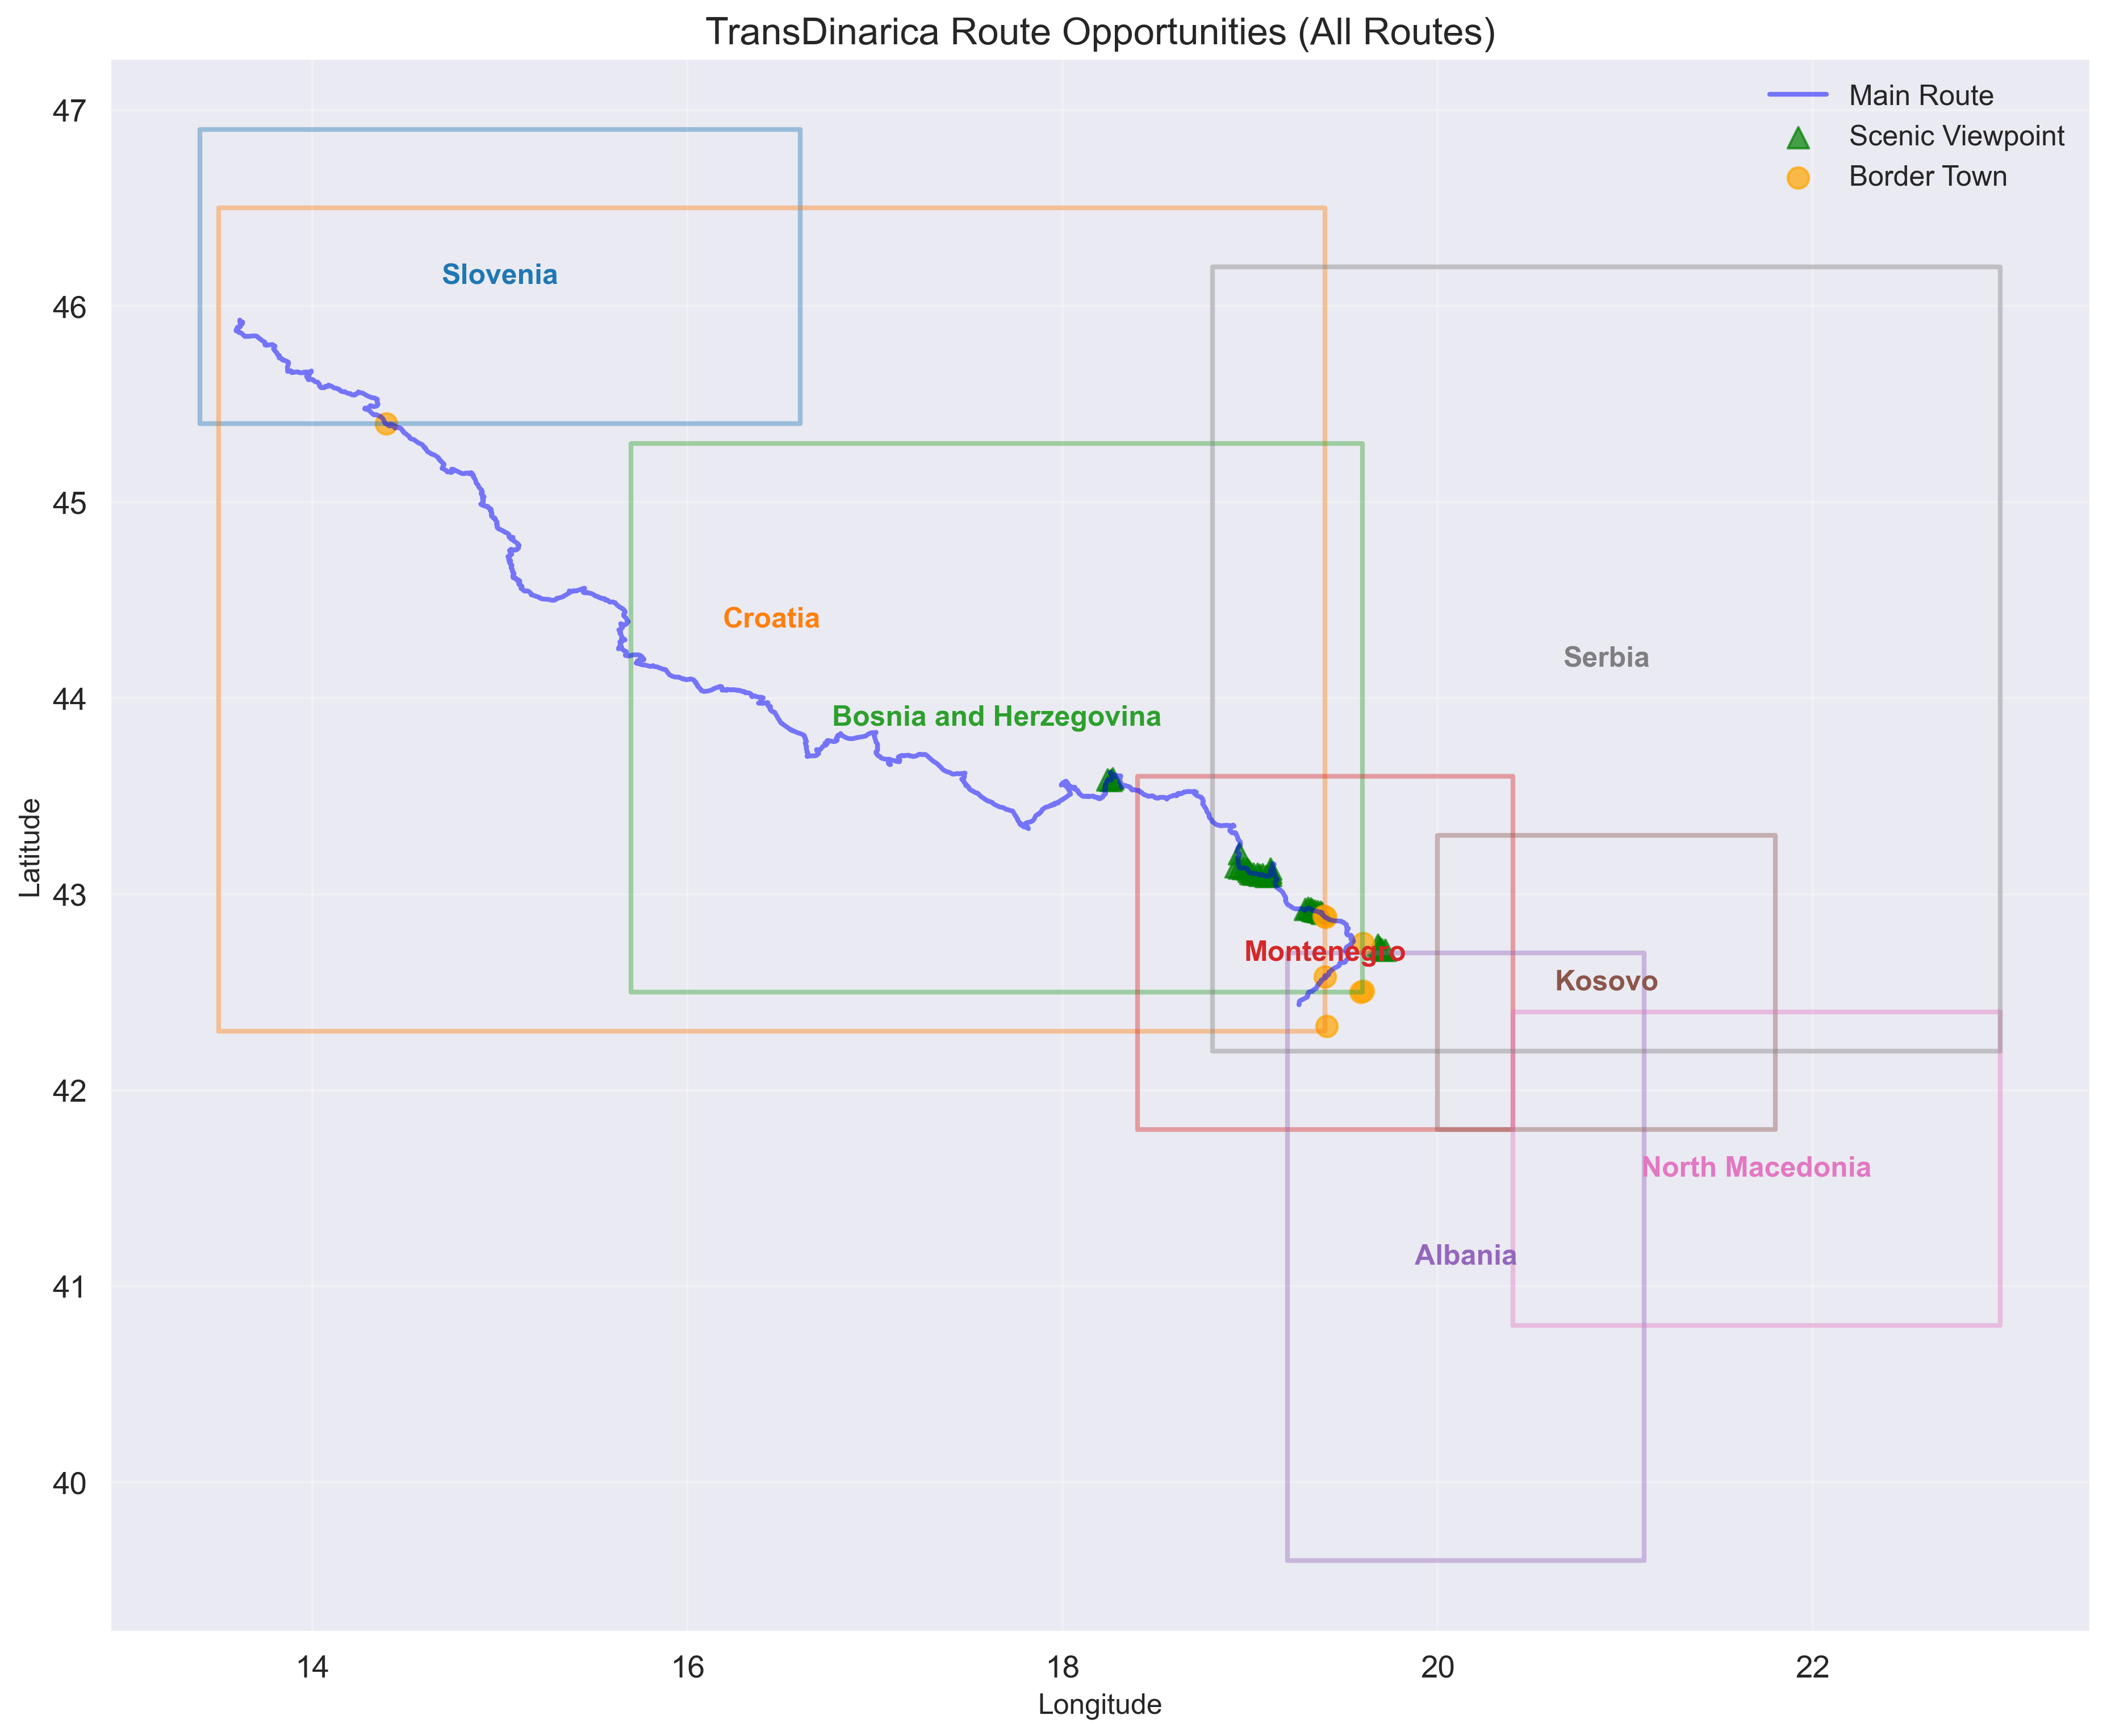

Comprehensive opportunity visualization saved to 'transdinarica_comprehensive_opportunities.png'


In [72]:

# 12. Opportunity Analysis
# ---------------------
def create_opportunity_visualization():
    """Create a visualization of opportunities along all routes"""
    # Set up the plot
    plt.figure(figsize=(15, 12))

    # Plot country boundaries
    for country, info in countries_info.items():
        bounds = info["bounds"]
        color = info["color"]

        # Create rectangle for country (simplified)
        lat_min, lat_max, lon_min, lon_max = bounds
        plt.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                 [lat_min, lat_min, lat_max, lat_max, lat_min],
                 color=color, linewidth=2, alpha=0.4)

        # Add country label
        plt.text((lon_min + lon_max)/2, (lat_min + lat_max)/2, country,
                 fontsize=12, ha='center', va='center', color=color, fontweight='bold')

    # Plot main route (use route 8 as the main route since it's the largest)
    main_route = None
    for route in routes:
        if route['file'] == 'transdinarica_8.gpx':  # Use the largest file as the main route
            main_route = route
            break

    if not main_route:
        main_route = routes[0]  # Fallback to first route

    # Sample points for display
    if len(main_route['points']) > 2000:
        sample_rate = len(main_route['points']) // 2000
        display_points = main_route['points'][::sample_rate]
    else:
        display_points = main_route['points']

    main_lats = []
    main_lons = []
    for p in display_points:
        try:
            if len(p) >= 2:
                lat, lon = float(p[0]), float(p[1])
                main_lats.append(lat)
                main_lons.append(lon)
        except (ValueError, TypeError):
            continue

    if main_lats and main_lons:
        plt.plot(main_lons, main_lats, 'b-', linewidth=2, alpha=0.5, label='Main Route')

    # Generate opportunity points from all routes
    viewpoints = []  # Scenic viewpoints based on elevation
    border_points = []  # Border towns/cultural opportunities

    # Process all routes
    for route in routes:
        points = route['points']
        if len(points) < 2:
            continue

        # Sample for large routes
        if len(points) > 2000:
            step = len(points) // 2000 + 1
            analysis_points = points[::step]
        else:
            analysis_points = points

        # Find high elevation points as potential scenic views
        for point in analysis_points:
            try:
                if len(point) > 2 and point[2] is not None:
                    lat, lon, ele = float(point[0]), float(point[1]), float(point[2])
                    if ele > 1500:  # High elevation - likely scenic view
                        viewpoints.append((lat, lon))
            except (ValueError, TypeError, IndexError):
                continue

        # Find border crossings for towns/cultural sites
        for i in range(1, len(analysis_points)):
            try:
                p1 = analysis_points[i-1]
                p2 = analysis_points[i]

                p1_lat, p1_lon = float(p1[0]), float(p1[1])
                p2_lat, p2_lon = float(p2[0]), float(p2[1])

                # Calculate midpoint
                mid_lat = (p1_lat + p2_lat) / 2
                mid_lon = (p1_lon + p2_lon) / 2

                # Check for border crossings
                country1 = identify_country(p1_lat, p1_lon, countries_info)
                country2 = identify_country(p2_lat, p2_lon, countries_info)

                # Border crossings often have towns/facilities
                if country1 != country2 and country1 != "Unknown" and country2 != "Unknown":
                    border_points.append((mid_lat, mid_lon))
            except Exception:
                continue

    # De-duplicate opportunity points by proximity
    def deduplicate_points(points, threshold_km=1.0):
        """Remove duplicate points that are very close to each other"""
        if not points:
            return []

        result = [points[0]]  # Start with first point

        for p in points[1:]:
            # Check if this point is too close to any existing point
            too_close = False
            for existing in result:
                if geodesic((p[0], p[1]), (existing[0], existing[1])).kilometers < threshold_km:
                    too_close = True
                    break

            if not too_close:
                result.append(p)

        return result

    # Deduplicate points before plotting
    viewpoints = deduplicate_points(viewpoints)
    border_points = deduplicate_points(border_points)

    # Plot opportunity points
    if viewpoints:
        view_lats, view_lons = zip(*viewpoints)
        plt.scatter(view_lons, view_lats, c='green', marker='^', s=80, alpha=0.7, label='Scenic Viewpoint')

    if border_points:
        border_lats, border_lons = zip(*border_points)
        plt.scatter(border_lons, border_lats, c='orange', marker='o', s=80, alpha=0.7, label='Border Town')

    plt.title('TransDinarica Route Opportunities (All Routes)', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.savefig('transdinarica_comprehensive_opportunities.png', dpi=300, bbox_inches='tight')
    plt.close()

    return 'transdinarica_comprehensive_opportunities.png'

# Create and display opportunities visualization
print("\nCreating comprehensive opportunity visualization...")
opportunities_image = create_opportunity_visualization()
display(Image(opportunities_image))
print("Comprehensive opportunity visualization saved to 'transdinarica_comprehensive_opportunities.png'")



Creating combined challenges and opportunities visualization...


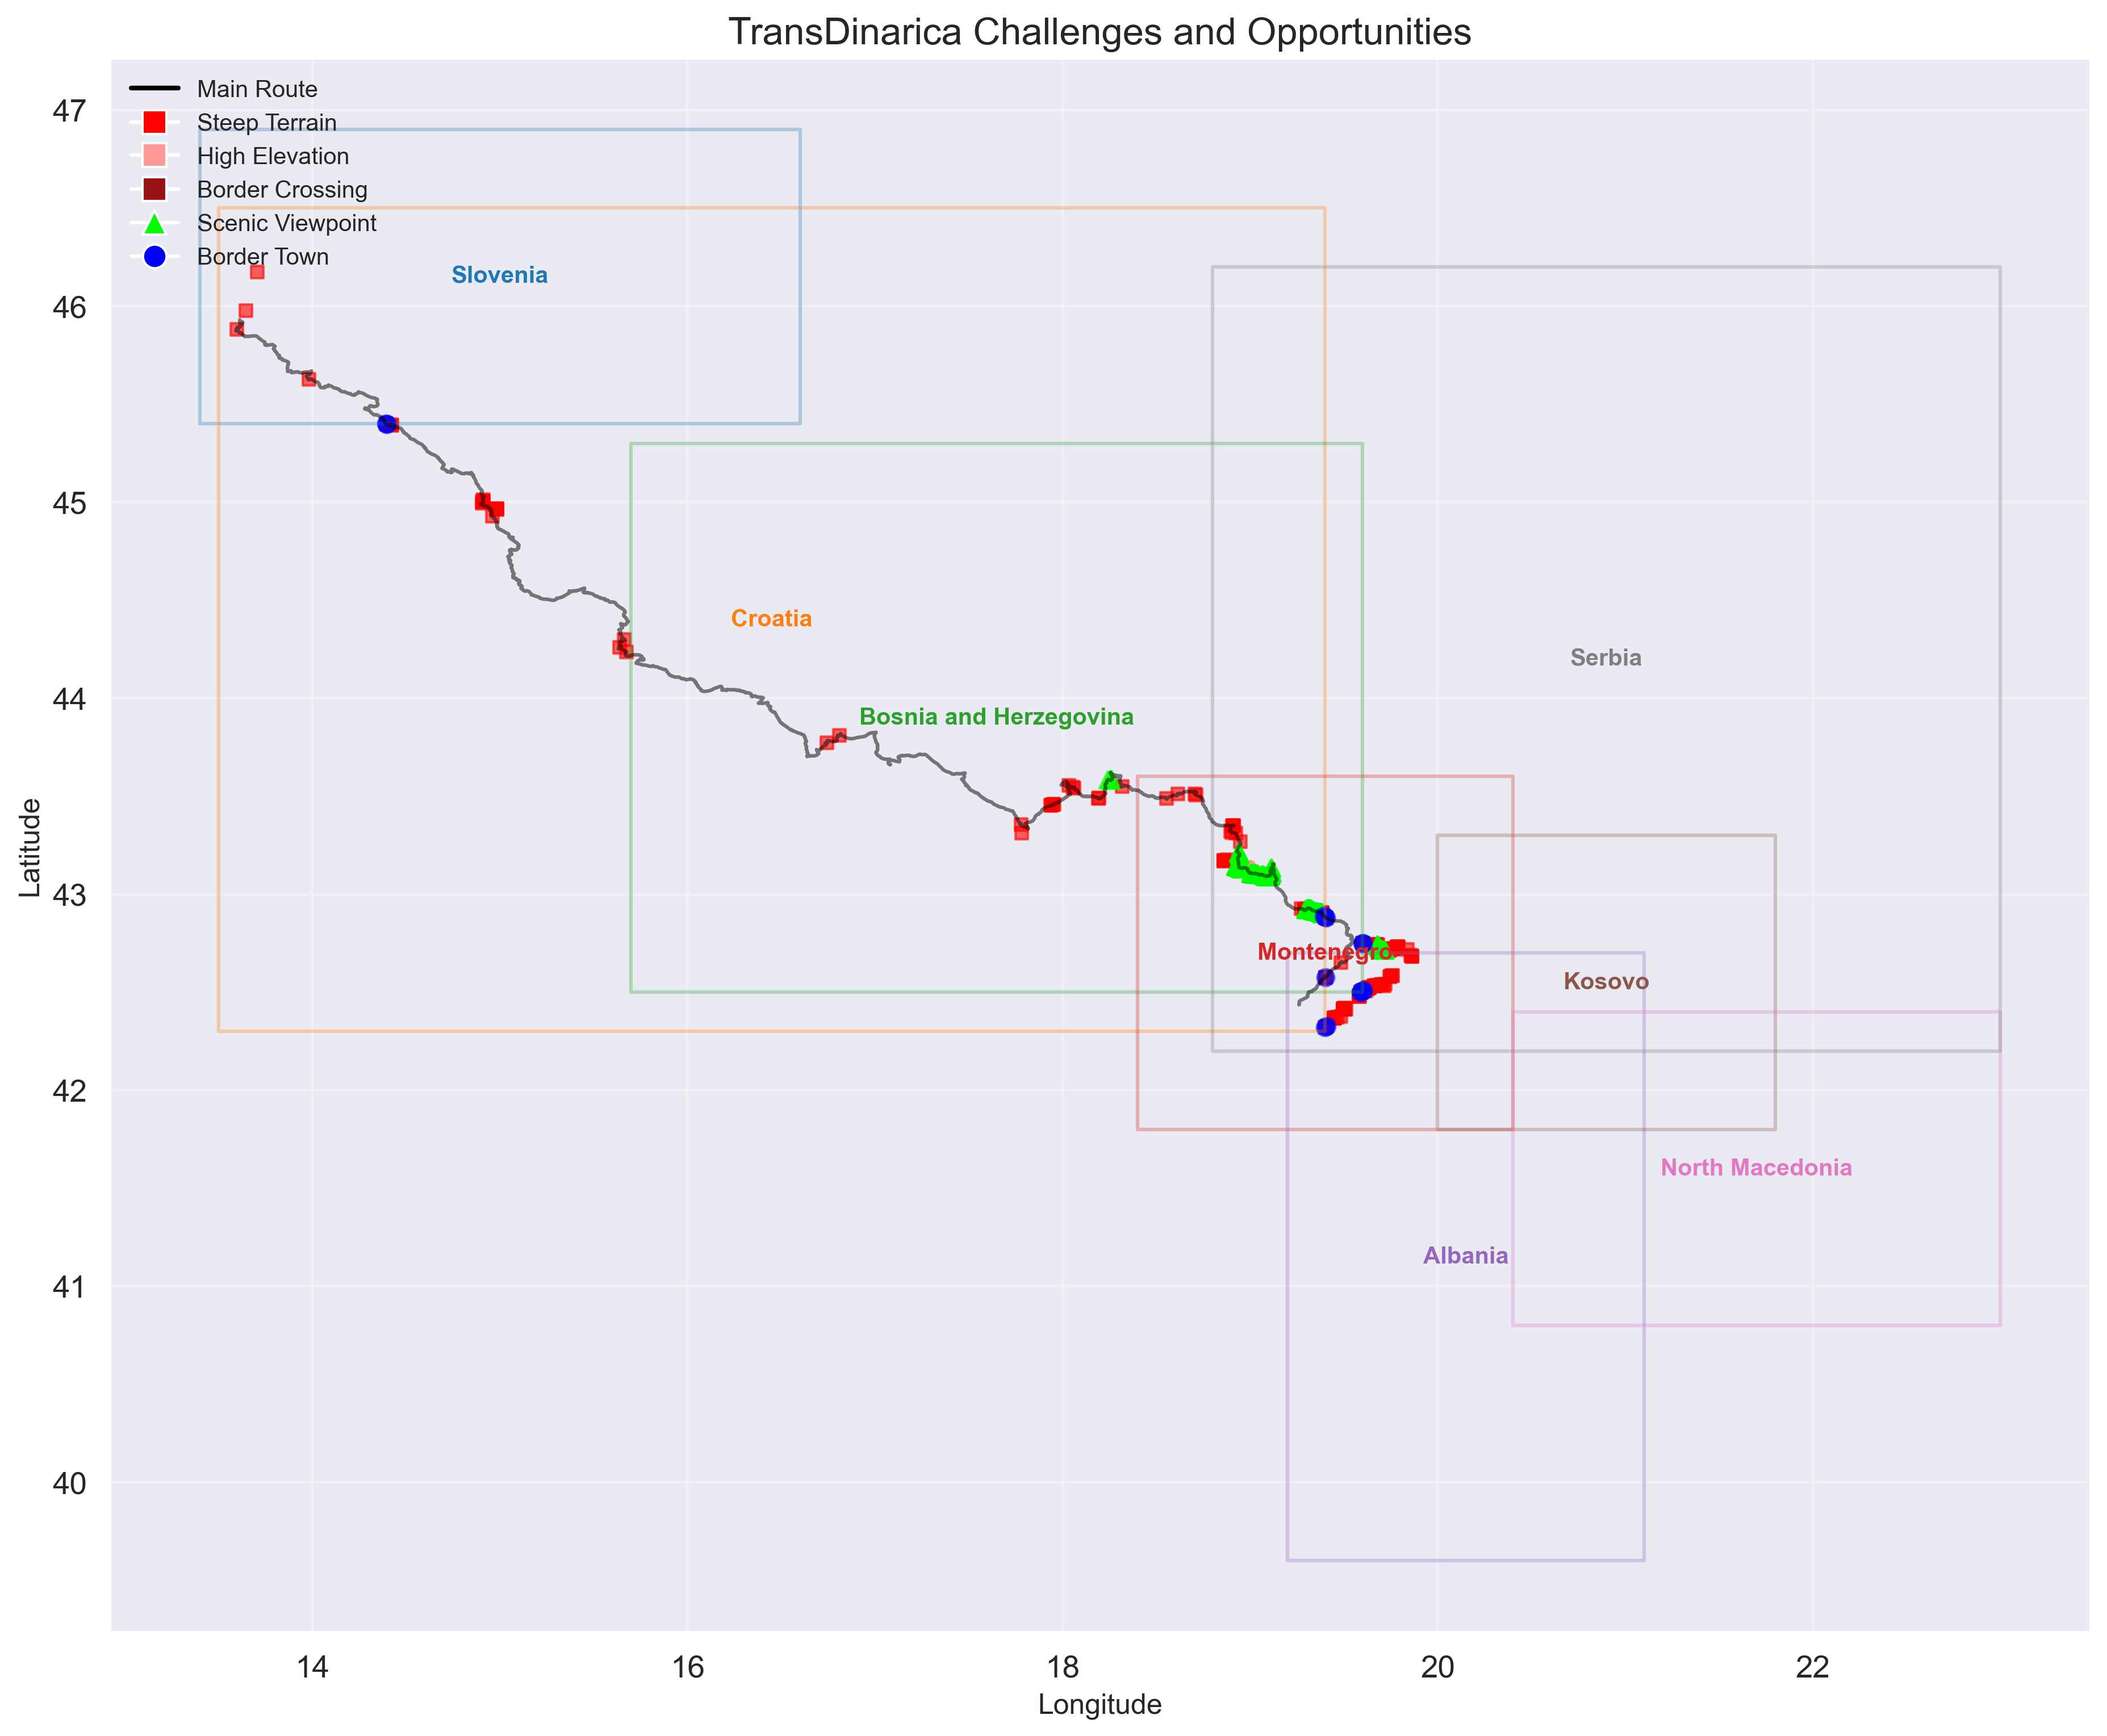

Combined visualization saved to 'transdinarica_complete_analysis.png'


In [73]:

# 13. Create Combined Challenges and Opportunities Map
# ------------------------------------------------
def create_combined_visualization():
    """Create a combined visualization showing both challenges and opportunities"""
    # Set up the plot
    plt.figure(figsize=(15, 12))

    # Plot country boundaries
    for country, info in countries_info.items():
        bounds = info["bounds"]
        color = info["color"]

        # Create rectangle for country (simplified)
        lat_min, lat_max, lon_min, lon_max = bounds
        plt.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                 [lat_min, lat_min, lat_max, lat_max, lat_min],
                 color=color, linewidth=1.5, alpha=0.3)

        # Add country label
        plt.text((lon_min + lon_max)/2, (lat_min + lat_max)/2, country,
                 fontsize=10, ha='center', va='center', color=color, fontweight='bold')

    # Plot main route (use route 8 as the main route since it's the largest)
    main_route = None
    for route in routes:
        if route['file'] == 'transdinarica_8.gpx':  # Use the largest file as the main route
            main_route = route
            break

    if not main_route:
        main_route = routes[0]  # Fallback to first route

    # Sample points for display
    if len(main_route['points']) > 2000:
        sample_rate = len(main_route['points']) // 2000
        display_points = main_route['points'][::sample_rate]
    else:
        display_points = main_route['points']

    main_lats = []
    main_lons = []
    for p in display_points:
        try:
            if len(p) >= 2:
                lat, lon = float(p[0]), float(p[1])
                main_lats.append(lat)
                main_lons.append(lon)
        except (ValueError, TypeError):
            continue

    if main_lats and main_lons:
        plt.plot(main_lons, main_lats, '-', color='black', linewidth=1.5, alpha=0.5, label='Main Route')

    # Get challenges and opportunities from earlier functions
    steep_points = []
    high_points = []
    border_points = []
    viewpoints = []
    border_towns = []

    # Process all routes
    for route in routes:
        points = route['points']
        if len(points) < 2:
            continue

        # Sample for large routes
        if len(points) > 1000:
            step = len(points) // 1000 + 1
            analysis_points = points[::step]
        else:
            analysis_points = points

        # Find all points of interest
        for i in range(1, len(analysis_points)):
            try:
                p1 = analysis_points[i-1]
                p2 = analysis_points[i]

                # Ensure we have valid coordinates
                p1_lat = float(p1[0])
                p1_lon = float(p1[1])
                p2_lat = float(p2[0])
                p2_lon = float(p2[1])

                # Calculate midpoint
                mid_lat = (p1_lat + p2_lat) / 2
                mid_lon = (p1_lon + p2_lon) / 2

                # CHALLENGES

                # Check for steep terrain
                slope = calculate_slope(p1, p2)
                if abs(slope) > 15:  # Steep slope
                    steep_points.append((mid_lat, mid_lon))

                # Check for high elevation
                if len(p1) > 2 and p1[2] is not None:
                    try:
                        elevation = float(p1[2])
                        if elevation > 1800:  # High elevation
                            high_points.append((p1_lat, p1_lon))
                        # OPPORTUNITIES
                        elif elevation > 1500:  # Scenic view
                            viewpoints.append((p1_lat, p1_lon))
                    except (ValueError, TypeError):
                        pass

                # Check for border crossings
                country1 = identify_country(p1_lat, p1_lon, countries_info)
                country2 = identify_country(p2_lat, p2_lon, countries_info)

                if country1 != country2 and country1 != "Unknown" and country2 != "Unknown":
                    border_points.append((mid_lat, mid_lon))  # Challenge
                    border_towns.append((mid_lat, mid_lon))   # Opportunity
            except Exception:
                continue

    # Deduplicate points before plotting
    viewpoints = list(set(viewpoints))
    border_towns = list(set(border_towns))

    # Plot challenges in red hues
    if steep_points:
        steep_lats, steep_lons = zip(*steep_points)
        plt.scatter(steep_lons, steep_lats, c='#FF0000', marker='s', s=30, alpha=0.6, label='Steep Terrain')

    if high_points:
        high_lats, high_lons = zip(*high_points)
        plt.scatter(high_lons, high_lats, c='#FF9999', marker='s', s=30, alpha=0.6, label='High Elevation')

    if border_points:
        border_lats, border_lons = zip(*border_points)
        plt.scatter(border_lons, border_lats, c='#991111', marker='s', s=30, alpha=0.6, label='Border Crossing')

    # Plot opportunities in green/blue hues
    if viewpoints:
        view_lats, view_lons = zip(*viewpoints)
        plt.scatter(view_lons, view_lats, c='#00FF00', marker='^', s=50, alpha=0.6, label='Scenic Viewpoint')

    if border_towns:
        town_lats, town_lons = zip(*border_towns)
        plt.scatter(town_lons, town_lats, c='#0000FF', marker='o', s=50, alpha=0.6, label='Border Town')

    plt.title('TransDinarica Challenges and Opportunities', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Create a two-part legend
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Main Route'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF0000', markersize=10, label='Steep Terrain'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF9999', markersize=10, label='High Elevation'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#991111', markersize=10, label='Border Crossing'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#00FF00', markersize=10, label='Scenic Viewpoint'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#0000FF', markersize=10, label='Border Town'),
    ]

    plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
    plt.savefig('transdinarica_complete_analysis.png', dpi=300, bbox_inches='tight')
    plt.close()

    return 'transdinarica_complete_analysis.png'

# Create and display combined visualization
print("\nCreating combined challenges and opportunities visualization...")
combined_image = create_combined_visualization()
display(Image(combined_image))
print("Combined visualization saved to 'transdinarica_complete_analysis.png'")


In [74]:

# 14. Summary
# ---------
print("\n=== TransDinarica Complete Route Analysis ===")
print("The following files have been generated:")
print("1. transdinarica_route_stats.csv - Route statistics")
print("2. transdinarica_country_stats.csv - Country statistics")
print("3. transdinarica_complete_map.png - Map of all routes")
print("4. transdinarica_country_analysis.png - Country distribution analysis")
print("5. transdinarica_comprehensive_challenges.png - All challenges")
print("6. all_elevation_profiles.png - Elevation profiles for all routes")
print("7. transdinarica_comprehensive_opportunities.png - All opportunities")
print("8. transdinarica_complete_analysis.png - Combined challenges and opportunities")

# Calculate total distance across all routes
total_distance = sum(stat['distance_km'] for stat in route_stats)
countries_count = len([c for c in country_distances.keys() if country_distances[c] > 0])
max_elevation = max(stat['max_elevation_m'] for stat in route_stats)
total_elevation_gain = sum(stat['elevation_gain_m'] for stat in route_stats)

print("\nKey findings:")
print(f"- Total route distance: {round(total_distance, 1)} km")
print(f"- Total elevation gain: {round(total_elevation_gain, 1)} m")
print(f"- Countries traversed: {countries_count}")
print(f"- Maximum elevation: {round(max_elevation, 1)} m")

if not country_df.empty:
    top_country = country_df.iloc[0]['Country']
    top_distance = country_df.iloc[0]['Distance_km']
    print(f"- {top_country} has the most route coverage: {top_distance} km")

print("\nThis analysis provides a comprehensive overview of the TransDinarica route.")
print("All eight GPX files have been processed to create a complete picture of the route network.")


=== TransDinarica Complete Route Analysis ===
The following files have been generated:
1. transdinarica_route_stats.csv - Route statistics
2. transdinarica_country_stats.csv - Country statistics
3. transdinarica_complete_map.png - Map of all routes
4. transdinarica_country_analysis.png - Country distribution analysis
5. transdinarica_comprehensive_challenges.png - All challenges
6. all_elevation_profiles.png - Elevation profiles for all routes
7. transdinarica_comprehensive_opportunities.png - All opportunities
8. transdinarica_complete_analysis.png - Combined challenges and opportunities

Key findings:
- Total route distance: 2356.2 km
- Total elevation gain: 39059.1 m
- Countries traversed: 4
- Maximum elevation: 1901.9 m
- Croatia has the most route coverage: 1621.2 km

This analysis provides a comprehensive overview of the TransDinarica route.
All eight GPX files have been processed to create a complete picture of the route network.
